# Lecture 13: Hypothesis Testing 2 — Testing Composite Hypotheses

**Data 145, Spring 2026: Evidence and Uncertainty**
**Instructors:** Ani Adhikari, William Fithian

---

**Please run all the code cells below before you start reading.**

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, poisson, t as t_dist

plt.style.use('fivethirtyeight')
%matplotlib inline

# Color scheme
COLOR_DATA = 'steelblue'
COLOR_APPROX = 'firebrick'

print("Setup complete.")

Setup complete.


---

## 1. Completing the NP Lemma Proof (from Lecture 12)

*This section completes material we started last time. In Lecture 12, we stated the Neyman-Pearson lemma and built the "bang for buck" intuition. Now we prove it, and then revisit the Poisson example to motivate the new material.*

### Quick Recap

Last time we saw that for testing simple $H_0: X \sim P_0$ vs simple $H_1: X \sim P_1$, the **likelihood ratio test** (LRT) — which rejects for large $\text{LR}(x) = f_1(x)/f_0(x)$ — maximizes power among all level-$\alpha$ tests. This is the **Neyman-Pearson lemma**.

The intuition: think of building a rejection region one sample point at a time. Each point $x$ costs $f_0(x)$ in Type I error ("buck") and buys $f_1(x)$ in power ("bang"). The LRT includes points in order of decreasing "bang for our buck" $\text{LR}(x) = f_1(x)/f_0(x)$ — a greedy algorithm. Now we prove it's optimal.

### Proof of the NP Lemma

**Setup.** We want to find a test $\phi(x) \in [0, 1]$ that maximizes power $E_1[\phi(X)]$ subject to the level constraint $E_0[\phi(X)] \leq \alpha$.

**Lagrangian approach.** Form the Lagrangian:

$$\mathcal{L}(\phi; \lambda) = E_1[\phi(X)] - \lambda E_0[\phi(X)] = \int \phi(x)\bigl(f_1(x) - \lambda f_0(x)\bigr)\,dx$$

(Here $\int \cdots dx$ is over $\mathbb{R}^n$ for an $n$-fold sample, or a sum $\sum_x$ for discrete distributions.)

**Pointwise maximization.** Since $\phi(x) \in [0, 1]$ for each $x$, we maximize the integrand pointwise:

$$\phi(x) = \begin{cases} 1 & \text{if } f_1(x) - \lambda f_0(x) > 0, \text{ i.e., } \text{LR}(x) > \lambda \\ 0 & \text{if } f_1(x) - \lambda f_0(x) < 0, \text{ i.e., } \text{LR}(x) < \lambda \end{cases}$$

This is exactly the LRT! The NP test $\phi^*$ that rejects when $\text{LR}(x) > c$ (with $c$ chosen so $E_0[\phi^*(X)] = \alpha$) maximizes the Lagrangian at multiplier $\lambda = c$.

**Note on ties.** When $\text{LR}(x) = \lambda$ exactly, the integrand is zero, so $\phi(x)$ can be anything in $[0, 1]$ without affecting the Lagrangian. This is why the NP test allows randomization at the boundary — it doesn't matter for optimality.

**Completing the proof.** For any competing test $\phi$ with $E_0[\phi(X)] \leq \alpha$:

$$E_1[\phi(X)] \leq E_1[\phi(X)] - c\bigl(E_0[\phi(X)] - \alpha\bigr) \leq E_1[\phi^*(X)] - c\bigl(E_0[\phi^*(X)] - \alpha\bigr) = E_1[\phi^*(X)]$$

- **First $\leq$**: Because $E_0[\phi(X)] \leq \alpha$, we have $E_0[\phi(X)] - \alpha \leq 0$, and $c > 0$, so we're *subtracting something non-positive* — the left side can only go up.
- **Second $\leq$**: Because $\phi^*$ maximizes the Lagrangian $E_1[\phi(X)] - c \cdot E_0[\phi(X)]$.
- **Final $=$**: Because $E_0[\phi^*(X)] = \alpha$, so the correction term vanishes. $\square$

**Interpretation.** The greedy algorithm — include sample points in order of decreasing "bang for buck" — is provably optimal.

### The Poisson Example, Revisited

Recall the **Poisson distribution**: $X \sim \text{Poisson}(\lambda)$ has PMF

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad k = 0, 1, 2, \ldots$$

Test $H_0: \lambda = 10$ vs $H_1: \lambda = 15$. The likelihood ratio is:

$$\text{LR}(X) = \frac{15^X e^{-15}/X!}{10^X e^{-10}/X!} = (15/10)^X \cdot e^{-5} = 1.5^X \cdot e^{-5}$$

Since $e^{-5}$ is a constant, $\text{LR}$ is **increasing in $X$** (since $1.5 > 1$), so the NP test rejects for large $X$.

But the same computation works for **any** $\lambda_1 > 10$:

$$\text{LR}(X) = (\lambda_1/10)^X \cdot e^{-(\lambda_1 - 10)}$$

This is still increasing in $X$ (since $\lambda_1/10 > 1$).

**Key observation.** The rejection region $\{X \geq c\}$ doesn't depend on which $\lambda_1 > 10$ we use. The same test is optimal against *every* $\lambda_1 > 10$ simultaneously. This is the idea behind **uniformly most powerful** tests — our next topic.

Let's make this concrete: at $\alpha = 0.05$, what does the rejection region look like?

Non-randomized test: reject if X >= 16
  Actual level = 0.0487 (< alpha = 0.05)

Randomized test: reject if X >= 16, or X = 15 with prob gamma = 0.0363
  Exact level = 0.05


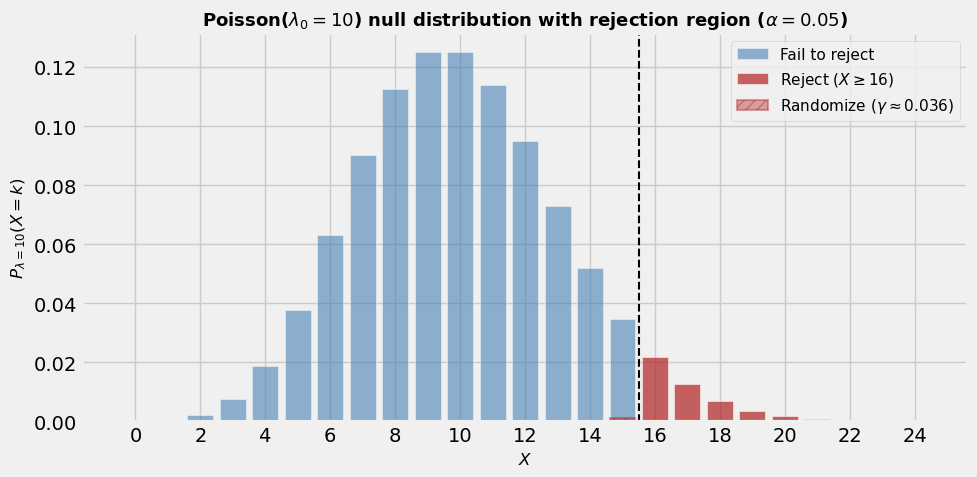

In [2]:
# Poisson NP test: H0: lambda = 10, alpha = 0.05
lambda_0 = 10.0
alpha_pois = 0.05

# Find non-randomized threshold: smallest c such that P(X >= c | lambda_0) <= alpha
c_nr = 0
while 1 - poisson.cdf(c_nr - 1, lambda_0) > alpha_pois:
    c_nr += 1

actual_level_nr = 1 - poisson.cdf(c_nr - 1, lambda_0)
print(f"Non-randomized test: reject if X >= {c_nr}")
print(f"  Actual level = {actual_level_nr:.4f} (< alpha = {alpha_pois})")

# Randomized threshold: reject if X > c_nr-1, randomize at X = c_nr-1
# P(X >= c_nr | lambda_0) = actual_level_nr
# Need gamma * P(X = c_nr-1) + P(X >= c_nr) = alpha
p_boundary = poisson.pmf(c_nr - 1, lambda_0)
gamma = (alpha_pois - actual_level_nr) / p_boundary
print(f"\nRandomized test: reject if X >= {c_nr}, or X = {c_nr - 1} with prob gamma = {gamma:.4f}")
print(f"  Exact level = {alpha_pois}")

# Plot null PMF with rejection region shaded
x_vals = np.arange(0, 25)
pmf_vals = poisson.pmf(x_vals, lambda_0)

fig, ax = plt.subplots(figsize=(10, 5))

# Non-rejection region (excluding boundary bar)
mask_accept = x_vals < (c_nr - 1)
mask_reject = x_vals >= c_nr
ax.bar(x_vals[mask_accept], pmf_vals[mask_accept], color=COLOR_DATA, alpha=0.6,
       edgecolor='white', label='Fail to reject')
ax.bar(x_vals[mask_reject], pmf_vals[mask_reject], color=COLOR_APPROX, alpha=0.7,
       edgecolor='white', label=f'Reject ($X \\geq {c_nr}$)')

# Boundary bar: blue base, then hatched red overlay for the gamma fraction
boundary_idx = c_nr - 1
boundary_height = pmf_vals[boundary_idx]
ax.bar([boundary_idx], [boundary_height], color=COLOR_DATA, alpha=0.6,
       edgecolor='white')
# Hatched red overlay showing gamma fraction
ax.bar([boundary_idx], [gamma * boundary_height], color=COLOR_APPROX, alpha=0.4,
       edgecolor=COLOR_APPROX, linewidth=1.5, hatch='///',
       label=f'Randomize ($\\gamma \\approx {gamma:.3f}$)')

ax.axvline(c_nr - 0.5, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('$X$', fontsize=12)
ax.set_ylabel('$P_{\\lambda=10}(X = k)$', fontsize=12)
ax.set_title(f'Poisson($\\lambda_0 = 10$) null distribution with rejection region ($\\alpha = {alpha_pois}$)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(x_vals[::2])
plt.tight_layout()
plt.show()

*__Figure 1.__ Null distribution $\text{Poisson}(10)$ with rejection region for $\alpha = 0.05$. The NP test rejects for large $X$: the red bars show $\{X \geq 16\}$. The dashed line marks the boundary. The hatched portion of the bar at $X = 15$ represents the randomized component of the test.*

### Computing $c$ and $\gamma$

The NP test rejects when $\text{LR}(X) > c$, or equivalently (since LR is increasing in $X$) when $X \geq c$. We choose $c$ to use up as much of the $\alpha = 0.05$ error budget as possible:

- **Non-randomized test**: Reject if $X \geq 16$. The level is $P_{\lambda=10}(X \geq 16) \approx 0.0487$, which is slightly below $\alpha = 0.05$.

- **Randomized test**: To hit level $\alpha = 0.05$ exactly, we also reject at the boundary value $X = 15$ with probability $\gamma$. We need:
$$\gamma \cdot P_{\lambda=10}(X = 15) + P_{\lambda=10}(X \geq 16) = 0.05$$
$$\gamma \cdot 0.0347 + 0.0487 = 0.05 \implies \gamma \approx 0.036$$

In practice, we always use the non-randomized version — the actual level of $0.0487$ is close enough to $0.05$ that the difference is negligible.

---

## 2. Uniformly Most Powerful Tests

### Definition

A level-$\alpha$ test $\phi^*$ is **uniformly most powerful (UMP)** if it maximizes power $E_{\theta_1}[\phi(X)]$ simultaneously for every $\theta_1 \in \Theta_1$.

UMP = "best of all worlds" — a single test that beats all level-$\alpha$ competitors at every alternative. This is usually too much to hope for, but **one-sided alternatives are special**.

### The Monotone Likelihood Ratio Property

**Definition.** A family $\{P_\theta\}$ has **monotone likelihood ratio (MLR)** in $T(X)$ if, for every $\theta_1 < \theta_2$, the likelihood ratio

$$\text{LR}(x) = \frac{f_{\theta_2}(x)}{f_{\theta_1}(x)}$$

is non-decreasing in $T(x)$.

In words: as $\theta$ increases, the distribution shifts in a way that makes $T(X)$ tend to be larger. Large values of $T$ are evidence for large $\theta$.

**Theorem (MLR $\Rightarrow$ UMP).** If the family has MLR in $T(X)$, then the test "reject for large $T(X)$" is UMP for

$$H_0: \theta \leq \theta_0 \quad \text{vs} \quad H_1: \theta > \theta_0$$

**Proof sketch.** For any fixed $\theta_1 > \theta_0$, the NP lemma says the optimal test rejects for large $\text{LR}(x) = f_{\theta_1}(x)/f_{\theta_0}(x)$. By the MLR property, this is the same as rejecting for large $T(X)$. Since the rejection region $\{T(X) \geq c\}$ doesn't depend on $\theta_1$, the *same test* is NP-optimal against every $\theta_1 > \theta_0$ — i.e., it's UMP.

**Why the null can be composite.** Our derivation uses the NP lemma, which is about testing the simple null $\theta = \theta_0$. But we stated the theorem for $H_0: \theta \leq \theta_0$. This works because in an MLR family, the power function $\beta(\theta)$ of the test "reject for large $T(X)$" is non-decreasing in $\theta$. So $\beta(\theta) \leq \beta(\theta_0) \leq \alpha$ for all $\theta \leq \theta_0$ — level is automatically controlled over the entire composite null.

### Examples

- **Poisson**: $\text{Poisson}(\lambda)$ has MLR in $X$ (we just showed this). Rejecting for large $X$ is UMP for $H_0: \lambda \leq \lambda_0$ vs $H_1: \lambda > \lambda_0$.

- **Normal mean** (known $\sigma^2$): $N(\mu, \sigma^2/n)$ has MLR in $\bar{X}$. Rejecting for large $\bar{X}$ is UMP for $H_0: \mu \leq \mu_0$ vs $H_1: \mu > \mu_0$.

*General fact (to be proved on Worksheet 7): One-parameter exponential families automatically have MLR in their sufficient statistic $T(X)$.*

### Visualizing UMP: The Poisson Power Function

The power function $\beta(\lambda)$ of the Poisson UMP test shows:
- $\beta(\lambda) \leq \alpha$ for all $\lambda \leq \lambda_0$ (level is controlled)
- $\beta(\lambda)$ is increasing for $\lambda > \lambda_0$ (power grows with the alternative)

We plot this for both the **non-randomized** test (reject if $X \geq c$, level slightly below $\alpha$) and the **randomized** test (exact level $\alpha$).

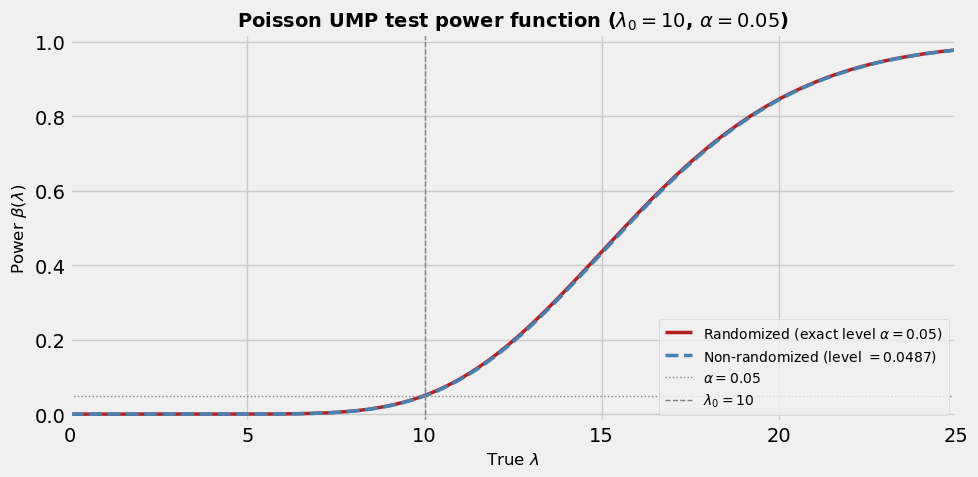

In [3]:
# Power function: randomized vs non-randomized Poisson UMP test
# Continuing from lambda_0 = 10, alpha = 0.05 defined above
lambda_grid = np.linspace(0.01, 25, 500)

# Non-randomized power: P(X >= c_nr | lambda)
power_nr = np.array([1 - poisson.cdf(c_nr - 1, lam) for lam in lambda_grid])

# Randomized power: gamma * P(X = c_nr-1 | lambda) + P(X >= c_nr | lambda)
power_rand = np.array([
    gamma * poisson.pmf(c_nr - 1, lam) + (1 - poisson.cdf(c_nr - 1, lam))
    for lam in lambda_grid
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambda_grid, power_rand, color=COLOR_APPROX, linewidth=2.5,
        label=f'Randomized (exact level $\\alpha = {alpha_pois}$)')
ax.plot(lambda_grid, power_nr, color=COLOR_DATA, linewidth=2.5, linestyle='--',
        label=f'Non-randomized (level $= {actual_level_nr:.4f}$)')
ax.axhline(alpha_pois, color='gray', linestyle=':', linewidth=1,
           label=f'$\\alpha = {alpha_pois}$')
ax.axvline(lambda_0, color='gray', linestyle='--', linewidth=1,
           label=f'$\\lambda_0 = {lambda_0:.0f}$')

ax.set_xlabel(r'True $\lambda$', fontsize=12)
ax.set_ylabel(r'Power $\beta(\lambda)$', fontsize=12)
ax.set_title(f'Poisson UMP test power function ($\\lambda_0 = {lambda_0:.0f}$, $\\alpha = {alpha_pois}$)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(-0.02, 1.02)
ax.set_xlim(0, 25)
plt.tight_layout()
plt.show()

*__Figure 2.__ Power function of the Poisson UMP test for $H_0: \lambda \leq 10$ vs $H_1: \lambda > 10$ at $\alpha = 0.05$. The red curve is the randomized test (exact level $\alpha$); the dashed blue curve is the non-randomized test (level slightly below $\alpha$). Both stay below $\alpha$ for $\lambda \leq 10$ and increase as $\lambda$ grows. The two curves are nearly indistinguishable — in practice, we always use the non-randomized version. This single test is simultaneously optimal against every $\lambda > 10$: that's what "uniformly most powerful" means.*

---

## 3. Two-Sided and Multidirectional Alternatives

### No UMP for Two-Sided Alternatives

Consider testing $H_0: \mu = \mu_0$ vs $H_1: \mu \neq \mu_0$ for $\bar{X} \sim N(\mu, \sigma^2/n)$ (with $\sigma^2$ known).

From the MLR property:
- The UMP test for $H_1: \mu > \mu_0$ rejects for **large** $\bar{X}$
- The UMP test for $H_1: \mu < \mu_0$ rejects for **small** $\bar{X}$

These are **different tests**! No single test can be UMP against both directions.

If a UMP for $H_1: \mu \neq \mu_0$ existed, it would have to beat the one-sided UMP at every alternative — including every $\mu > \mu_0$ and every $\mu < \mu_0$. But the one-sided UMP is already NP-optimal for each direction separately, so no single test can beat both. Contradiction.

### The Two-Sided $z$-Test

$Z \sim N(\theta, 1)$; test $H_0: \theta = 0$ vs $H_1: \theta \neq 0$.

Since no UMP exists, we must make a choice. We could split the rejection region into two tails: reject if $Z > z_{\alpha_1}$ or $Z < -z_{\alpha_2}$, where $\alpha_1 + \alpha_2 = \alpha$.

Putting more mass in the right tail ($\alpha_1 > \alpha_2$) gives more power for $\theta > 0$ but less power for $\theta < 0$. No single split dominates everywhere.

The **equal-tailed** test ($\alpha_1 = \alpha_2 = \alpha/2$) is the standard default:

$$\text{Reject if } |Z| > z_{\alpha/2}$$

This treats both directions symmetrically — a natural choice when we have no reason to expect the alternative to favor one direction over the other.

### Multidirectional Alternatives: No Free Lunch

Two-sided testing is a special case of a broader problem: **multidirectional alternatives**.

Consider the Benford example from Lecture 12. The LRT was optimal for the specific alternative $H_1$: Uniform. But what if the alternative were a *different* non-Benford distribution — say, one that overweights digit 1 even more than Benford does? The Uniform-LRT would lose power against this alternative, while TV distance or KS (which measure generic distance from Benford) might do better.

**No free lunch**: when the alternative is composite or multidirectional, no single test dominates. The choice of test statistic embodies our beliefs about which alternatives are more plausible.

We'll explore this further on Worksheet 7 and see a principled approach — the **generalized likelihood ratio test** — in Lecture 15.

---

## 4. Nuisance Parameters: The $t$-Test

### The Problem

So far, all our tests assume we know the null distribution completely (simple $H_0$). But in practice, other unknowns — **nuisance parameters** — affect the distribution.

**Example.** Test $H_0: \mu = \mu_0$ when $X_1, \ldots, X_n \overset{\text{iid}}{\sim} N(\mu, \sigma^2)$ with $\sigma^2$ unknown.

The $z$-test rejects when $\bar{X} \geq \mu_0 + z_\alpha \cdot \sigma/\sqrt{n}$, but the threshold depends on $\sigma$! If we don't know $\sigma$, we can't compute the rejection threshold.

We need a test whose null distribution **doesn't depend on the nuisance parameter**.

### The $t$-Test

**Idea:** Replace the unknown $\sigma$ with the sample standard deviation:

$$S = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(X_i - \bar{X})^2}$$

**Key facts** (Cochran's theorem): Under the Normal model, $\bar{X}$ and $S^2$ are **independent**, and $(n-1)S^2/\sigma^2 \sim \chi^2_{n-1}$. We'll prove this independence and discuss $t$-tests in more generality when we study the multivariate Normal distribution later in the course. For now, the key consequence is that the **$t$-statistic**:

$$T = \frac{\bar{X} - \mu_0}{S/\sqrt{n}} \sim t_{n-1} \quad \text{under } H_0$$

follows a $t$-distribution with $n - 1$ degrees of freedom — **regardless of the value of $\sigma^2$!**

The $t$-test rejects for large $|T|$ (two-sided) or large $T$ (one-sided): a valid level-$\alpha$ test no matter what $\sigma^2$ is.

### The $t$-Distribution

The $t_{n-1}$ distribution looks like a Standard Normal but with **heavier tails**, especially for small $n$. As $n$ grows, $t_{n-1}$ approaches $N(0, 1)$.

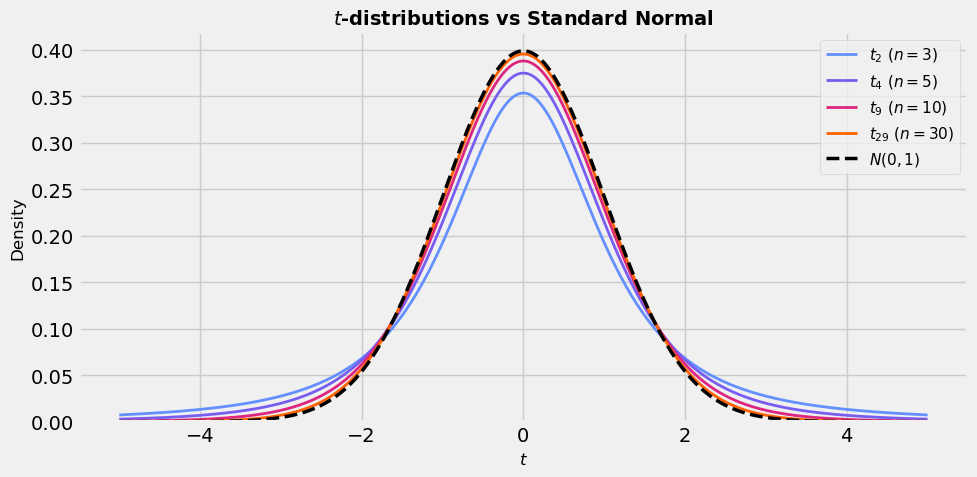

In [4]:
# t-densities for several df vs N(0,1)
x = np.linspace(-5, 5, 500)

fig, ax = plt.subplots(figsize=(10, 5))

# IBM colorblind-safe palette for multiple curves
colors = ['#648FFF', '#785EF0', '#DC267F', '#FE6100']
df_values = [2, 4, 9, 29]
n_values = [3, 5, 10, 30]

for df, n_val, color in zip(df_values, n_values, colors):
    ax.plot(x, t_dist.pdf(x, df), color=color, linewidth=2,
            label=f'$t_{{{df}}}$ ($n = {n_val}$)')

# Standard Normal for comparison
ax.plot(x, norm.pdf(x), color='black', linewidth=2.5, linestyle='--',
        label='$N(0, 1)$')

ax.set_xlabel('$t$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('$t$-distributions vs Standard Normal', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

*__Figure 3.__ Densities of the $t$-distribution with $n - 1$ degrees of freedom for $n = 3, 5, 10, 30$, compared with the Standard Normal $N(0, 1)$ (dashed black). The $t$-distribution has heavier tails than the Normal, especially for small $n$: the extra uncertainty from estimating $\sigma$ makes extreme values more likely. As $n$ grows, $t_{n-1} \to N(0, 1)$.*

### Why Does It Work?

The key insight: $T = (\bar{X} - \mu_0)/(S/\sqrt{n})$ is a **pivotal quantity** — its distribution under $H_0$ doesn't depend on any unknown parameters.

This is possible because $\bar{X}$ and $S^2$ are independent (Cochran's theorem): dividing by $S$ "scales out" the unknown $\sigma$.

- For **large $n$**: By Slutsky's lemma, $S \xrightarrow{p} \sigma$, so the $t$-statistic has approximately the same distribution as the $z$-statistic. The $t$-test and $z$-test give essentially the same answer.
- For **small $n$**: The exact result $T \sim t_{n-1}$ matters — the $t$-distribution's heavier tails correctly account for the extra uncertainty in estimating $\sigma$.

In future lectures we'll discuss other ways of dealing with nuisance parameters (conditioning, permutation tests, etc.).

### The Two-Sample $t$-Test

The same pivotal-quantity idea extends to comparing two means.

**Setup.** $X_1, \ldots, X_m \overset{\text{iid}}{\sim} N(\mu_X, \sigma^2)$ and $Y_1, \ldots, Y_n \overset{\text{iid}}{\sim} N(\mu_Y, \sigma^2)$, independent. Test $H_0: \mu_X = \mu_Y$. The nuisance parameter is again $\sigma^2$.

**Solution.** Pool the two samples to estimate $\sigma^2$:

$$S_p^2 = \frac{(m-1)S_X^2 + (n-1)S_Y^2}{m + n - 2}$$

By Cochran's theorem, $(m-1)S_X^2/\sigma^2 \sim \chi^2_{m-1}$ and $(n-1)S_Y^2/\sigma^2 \sim \chi^2_{n-1}$, independently. Since the sum of independent $\chi^2$ random variables is again $\chi^2$, we get $(m+n-2)S_p^2/\sigma^2 \sim \chi^2_{m+n-2}$.

The two-sample $t$-statistic:

$$T = \frac{\bar{X} - \bar{Y}}{S_p\sqrt{1/m + 1/n}} \sim t_{m+n-2} \quad \text{under } H_0$$

Same principle: $T$ is a pivotal quantity whose null distribution doesn't depend on $\sigma^2$.

---

## 5. Summary and Next Time

### The Big Picture: Testing Composite Hypotheses

Last time we solved the simple-vs-simple problem (NP lemma). Today's theme: what happens when the hypotheses are **composite**?

We saw three flavors of composite hypotheses, each requiring different tools:

1. **One-sided composite alternative** ($H_1: \theta > \theta_0$): Many alternatives, but all in the same direction. The MLR property gives a **UMP** test — a single test that's optimal against every alternative simultaneously.

2. **Two-sided / multidirectional composite alternative** ($H_1: \theta \neq \theta_0$, or Benford vs many non-Benford distributions): Alternatives pull in conflicting directions. **No UMP exists** — the choice of test statistic embodies our beliefs about which alternatives are most plausible.

3. **Composite null** via nuisance parameters ($H_0: \mu = \mu_0$ with $\sigma^2$ unknown): The null itself isn't fully specified. We need a **pivotal quantity** whose null distribution doesn't depend on the nuisance.

### Key Takeaways

1. **NP lemma**: the LRT is provably optimal for simple vs simple — the "bang for buck" greedy algorithm works
2. **UMP tests** exist for one-sided alternatives in MLR families: the same test beats all level-$\alpha$ competitors at every alternative
3. **Two-sided/multidirectional**: no single test is best everywhere. The equal-tailed test is the symmetric default; for multidirectional alternatives, the choice of test statistic depends on what alternatives we care about
4. **Nuisance parameters**: the $t$-test creates a pivotal quantity that eliminates the nuisance $\sigma^2$; more examples to come

### Next Time (Lecture 14)

- Formal treatment of **$p$-values** (composite nulls, super-uniformity)
- **Confidence regions** and their correct interpretation
- **Test–confidence interval duality**: inverting a test to get a CI and vice versa
- Common misinterpretations of hypothesis tests